# Lesson157 · Open-source contribution: make your evidence reviewable

Student lab · PROVIDED / TODO / CHECK / EXIT. Default requires numpy and IPython. Three live functions verify the actual package evidence and write your claim report. Full training requires the separately pinned GPU environment.

In [ ]:
# Default: offline evidence replay. Full GPU training is explicitly opt-in.
import base64,hashlib,io,json,math,os,statistics,subprocess,sys,tempfile,zipfile
from pathlib import Path
import numpy as np
from IPython.display import display,Markdown
RUN_FULL_REPRODUCTION=False
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')


In [ ]:
# PROVIDED: compact release transport; it contains no raw databases or weights.
PACKAGE_B64='...'
raw=base64.b64decode(PACKAGE_B64)
assert hashlib.sha256(raw).hexdigest()=='1698859e6ae0d621c9bb60b4281d0d55d886b86ec4d212fce4c98205329a3bdc'
workspace=tempfile.TemporaryDirectory(prefix='l157-notebook-');PACKAGE_ROOT=Path(workspace.name)
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
 for item in archive.infolist():
  rel=Path(item.filename)
  assert not rel.is_absolute() and '..' not in rel.parts
  assert (item.external_attr>>16)&0o170000 != 0o120000
  dest=PACKAGE_ROOT/rel;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(archive.read(item))
EVIDENCE_ROOT=PACKAGE_ROOT/'labs/evidence/l157'


## 1 · Make your result usable by someone who was not there

**Reading route.** Choose a bounded claim → separate replay from training → inspect manifests → verify the package → prepare public review.

**Your win:** turn an experiment into a reviewable contribution whose commands, evidence and claims agree. Core lesson: about 25 minutes. Lab: one focused session; fresh training is a separate optional run.

[Lesson 156](https://avistian.github.io/relational/lessons/0156-temporal-leakage-audit.html) traced information through a full F1 pipeline. Its remaining gap is practical: another researcher should not need our workspace, caches or conversation to check the result. This lesson closes that gap with a standalone package. It serves the mission by making a concrete RDL result inspectable by a skeptical reader.

A **reproduction** repeats a specified computation. An **evidence replay** checks previously saved inputs and outputs. A **contribution** gives other people something they can use and review. A public URL establishes access; it does not establish correctness, acceptance by maintainers or learner mastery.

Retrieve: what does a temporal sampler fail to tell you about feature-processor fitting?

Start with the [RelBench contribution guide](https://github.com/stanford-star/relbench/blob/main/CONTRIBUTING.md). Its current tests use small synthetic fixtures, rather than full training loops. Our archived experiment belongs in a reproducibility package; a proposed upstream change needs a focused regression test against current upstream. The [pinned reference implementation](https://github.com/stanford-star/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/gnn_node.py) is the scientific baseline, not an assertion about today's code.



## 2 · Pick a contribution that follows from the evidence

There are two reasonable routes. A **reproducibility repository** gives readers a complete experiment, environment and report. An **upstream PR** changes an existing project and must fit its current interface, policies and tests. We choose the repository route because the evidence establishes a historical implementation and a declared policy sensitivity. It does not yet establish a defect in current upstream.

Our named experiment is **L157 — RelBench F1 temporal-audit reproducibility release**. The released baseline fits dated processors through 2010. Our intervention fits dated type discovery, vocabularies and statistics through 2005, then transforms all permitted graph rows. Sampling still uses each query's cutoff. Static versions and schedule publication histories remain unknown.

An accurate contribution title is: **“Reproduce F1 preprocessing policies with explicit fit-horizon audits.”** An inaccurate title is: “Prove RelBench leaks and fix its benchmark.” The stronger title requires evidence that we do not have. Likewise, neither a lower nor a higher corrected score decides which information policy matches a deployment.

Predict: do ten completed runs establish missing feature-arrival histories? Explain before reading further.



## 3 · Separate the two commands and the two manifests

<figure class="route-figure" tabindex="0">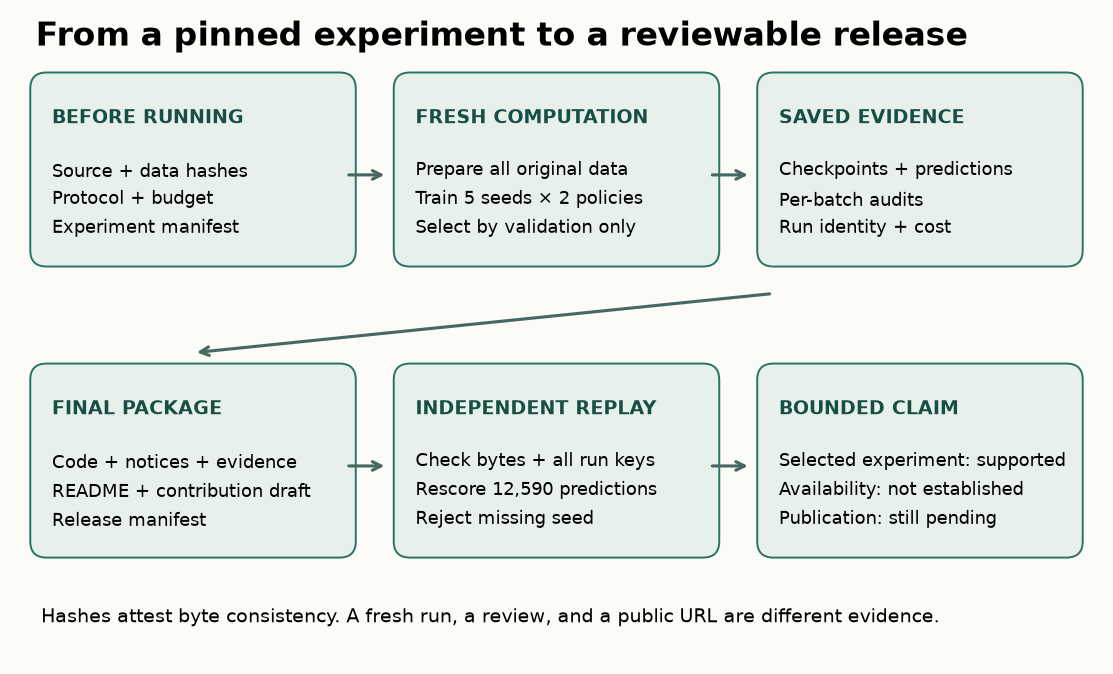<figcaption>Actual evidence path: freeze computation, run complete experiments, package and independently replay, then restrict the claim.</figcaption></figure>

`cli.py replay` is cheap: it verifies saved evidence, reconstructs all archived labels, checks complete query keys and epochs, rescores predictions and applies claim gates. It does **not** rerun feature SQL or train a model. `cli.py prepare` downloads the exact inputs and independently reconstructs the SQL features. `cli.py train` builds the actual graph, fits a complete seed and saves its selected checkpoint. Ten seed commands reproduce the two full lanes.

The **experiment manifest** freezes the executable source and protocol before dispatch. Each completed run records its digest. The **release manifest** covers the final deliverable, including documentation and saved evidence. Separating them allows us to add measured results without pretending those results existed before training. Neither manifest authenticates the author's identity: an attacker who replaces both bytes and hashes can forge consistency.

Worked trace: `paper/seed-0/predictions.npz` has a frozen digest. Integrity checking detects a changed byte. The evaluator then checks every `(driver_id, cutoff)` key, aligns targets, and independently computes mean absolute error. Finally it checks that all five seeds exist. Only after these steps can a summary support the **selected experiment** claim. A SHA256 match alone cannot replace the latter checks.



**TODO1:** implement this integrity function in the notebook. **CHECK:** change a byte, remove a file, and substitute a symlink. All must fail. **Recall:** why can an authentic-looking hash still fail to prove the scientist's conclusion?



In [ ]:
# TODO: used on the actual released evidence below.
def verify_manifest(root,files):
    raise NotImplementedError("TODO: verify_manifest")

In [ ]:
# CHECK: wrong evidence must change the verdict.
def rejects(call):
    try:call()
    except (ValueError,FileNotFoundError):return
    raise AssertionError('Invalid contribution accepted')
def fixtures():
    return [dict(lane=lane,seed=s,epochs=10,train_queries=7453,val_rows=499,test_rows=760,status='COMPLETE',test_mae=4+s/10) for lane in ['paper','fit_horizon'] for s in range(5)]
def check_integrity(fn):
    with tempfile.TemporaryDirectory() as tmp:
        root=Path(tmp);(root/'result').write_bytes(b'original')
        digest=hashlib.sha256(b'original').hexdigest();m={'result':digest}
        assert fn(root,m)==1
        (root/'result').write_bytes(b'changed');rejects(lambda:fn(root,m))
        rejects(lambda:fn(root,{'../escape':digest}))
        rejects(lambda:fn(root,{'/absolute':digest}))
        rejects(lambda:fn(root,{}))
        (root/'alias').symlink_to(root/'result');rejects(lambda:fn(root,{'alias':hashlib.sha256(b'changed').hexdigest()}))
check_integrity(verify_manifest)
print("PASS verify_manifest")

## 4 · A complete recipe must survive leaving this checkout

The [downloadable package](https://avistian.github.io/relational/labs/releases/l157-f1-audit.zip) contains visible graph/model/trainer code, independent audits, original licensed reference files, exact primary dependency versions, a pinned GPU image recipe, download hashes, the full protocol and compact evidence. Its [README](https://avistian.github.io/relational/labs/releases/l157-f1-audit/README.md) contains complete commands.

The fixed environment is Python 3.11, Torch 2.5.1/CUDA12.4, Frame 0.2.3, PyG 2.6.1 and pyg-lib 0.4.0, plus the pinned requirements. This specifies primary versions and records actual installed versions; it is not a hash lock of every transitive dependency or a guarantee that upstream downloads stay online.

Code and data rights are separate. Preserve the [RelBench MIT notice](https://github.com/stanford-star/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/LICENSE). Our release does not bundle raw archives or pretrained weights. The pinned user-study repository had no root license at the inspected location, so the SQL is fetched from its original URL and hash-checked rather than relicensed inside this archive. Read the [third-party notices](https://avistian.github.io/relational/labs/releases/l157-f1-audit/THIRD_PARTY_NOTICES.md) before redistributing additional inputs.

The full recipe uses every 7,453 training, 499 validation and 760 test query; five seeds per policy; ten epochs per seed; two 128-channel sum-GraphSAGE layers; uniform 128/64 sampling; Adam 0.005; batch 512; L1; first strict minimum validation MAE; and training-target percentile clipping. [Protocol](https://avistian.github.io/relational/labs/releases/l157-f1-audit/protocol.json). A smaller pilot or a subset of seeds cannot stand in for that recipe. Full model, sampler, trainer and correction are visible in the notebook's optional reproduction section.



## 5 · Count the evidence before summarizing it



**TODO2:** produce a complete-seed summary. **CHECK:** delete the last intervention seed. The result must say INCOMPLETE and omit aggregate scores. Duplicate seed0 does not replace missing seed4. A ten-epoch trace must also show full training populations at every epoch; the independent evaluator checks these details before this summary receives a record.

| Fresh L157 lane | Validation MAE | Test MAE | Availability |
|---|---:|---:|---|
| Released baseline | 3.181057 ± 0.023513 | 4.015191 ± 0.150212 | NOT_ESTABLISHED |
| Fixed-2005 intervention | 3.216675 ± 0.015079 | 4.073480 ± 0.250688 | NOT_ESTABLISHED |


<figure class="route-figure" tabindex="0">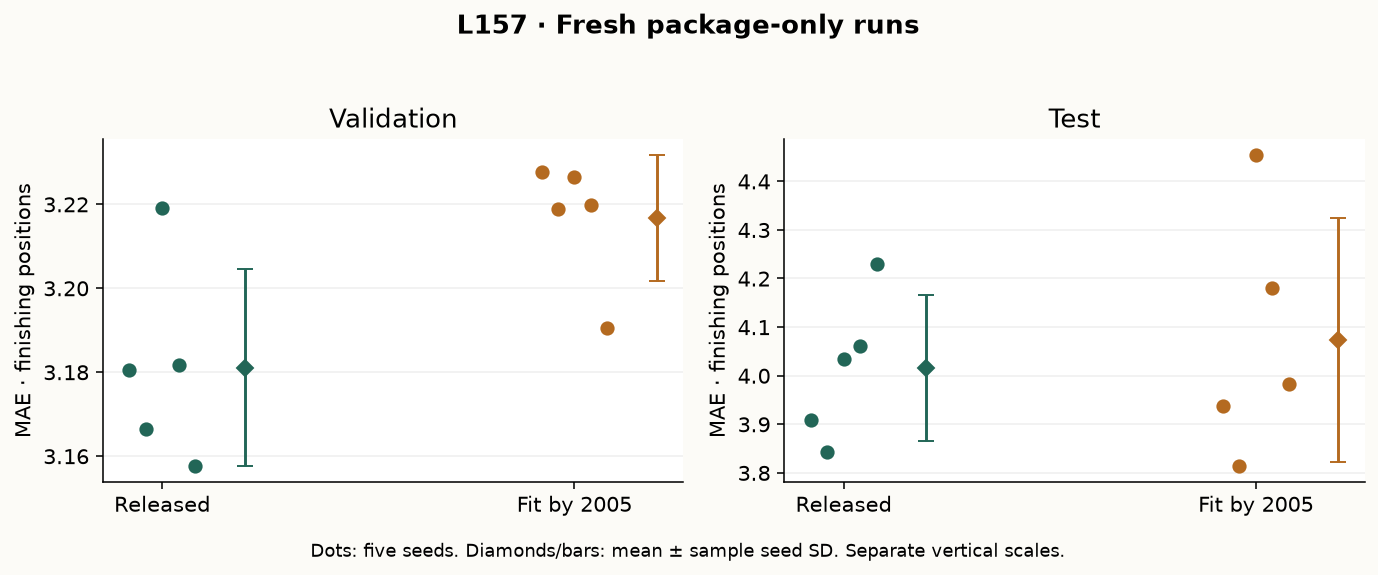<figcaption>New L157 five-seed results per policy. Mean and sample seed SD; separate validation/test scales.</figcaption></figure>

**Measured policy difference:** corrected minus released test MAE = **+0.058289**. Positive means the correction has higher error. The released mean is **CLOSE** to the paper test target under the frozen tolerance.

These are new L157 runs from the standalone package, separate from L156's earlier measurements. Seed SD describes variability across these five fits, not uncertainty over all possible relational databases. Integer seed matching does not ensure identical initialized weights when preprocessing changes encoder dimensions. The policy difference is descriptive; it does not establish superiority or equivalence.

**Coverage:** ten complete fresh fits; all **8,712 labels** reconstructed; **443,552 SQL values** independently checked during isolated preparation; **12,590 held-out predictions** independently rescored. Both lanes check every yielded batch, original node/edge identities and each root's query cutoff. First-backward nonfinite entries per released seed: [640, 640, 640, 640, 640].

The released lane's ±0.20 descriptive comparison is with the [RelBench paper](https://arxiv.org/html/2407.20060v1) Table 7 basic GNN target, validation 3.193 / test 4.022. The fixed-horizon intervention is not that paper experiment. Historical archive identity and actual feature availability remain NOT_ESTABLISHED. The source numeric encoder's nonfinite first-backward entries are retained and disclosed, not silently repaired.

**Cost boundary:** **$7.88 reserved resources plus overhead** against the approved **$10 total cap**. This is a conservative ledger, not an itemized invoice. Preparation, failures and validation count toward the cap; full runs are stopped rather than silently shortened. [Budget ledger](https://avistian.github.io/relational/labs/releases/l157-f1-audit/budget.json).



In [ ]:
# TODO: used on the actual released evidence below.
def summarize_runs(rows):
    raise NotImplementedError("TODO: summarize_runs")

In [ ]:
# CHECK: wrong evidence must change the verdict.
def rejects(call):
    try:call()
    except (ValueError,FileNotFoundError):return
    raise AssertionError('Invalid contribution accepted')
def fixtures():
    return [dict(lane=lane,seed=s,epochs=10,train_queries=7453,val_rows=499,test_rows=760,status='COMPLETE',test_mae=4+s/10) for lane in ['paper','fit_horizon'] for s in range(5)]
def check_runs(fn):
    rows=fixtures();r=fn(rows)
    assert r['status']=='COMPLETE' and r['fits']==10 and r['predictions']==12590
    assert abs(r['lanes']['paper']['mean']-4.2)<1e-12
    assert abs(r['lanes']['paper']['sd']-0.15811388300841897)<1e-12
    assert fn(rows[:-1])['status']=='INCOMPLETE'
    rejects(lambda:fn(rows+[rows[0]]))
    for key,value in [('epochs',9),('train_queries',100),('test_rows',0),('test_mae',float('nan')),('seed',9),('lane','unknown'),('status','PILOT')]:
        bad=[dict(x) for x in rows];bad[0][key]=value
        rejects(lambda:fn(bad))
check_runs(summarize_runs)
print("PASS summarize_runs")

## 6 · Review the claim as carefully as the code

Try the three CHECK fixtures: changed evidence, missing seed, unsupported historical claim. Predict each verdict before executing.



**TODO3:** gate the requested statement using its required evidence. **CHECK:** ten verified fits can support selected reproduction while historical availability remains unknown and the public contribution stays PENDING_PUBLICATION. Supplying a URL alone only moves publication to NOT_CHECKED: a reviewer still needs to visit it and verify the released artifact.

The [contribution draft](https://avistian.github.io/relational/labs/releases/l157-f1-audit/CONTRIBUTION_DRAFT.md) states the question, source pin, exact commands, expected/observed contract, complete result and limitations. It invites discussion of preprocessing policy rather than declaring a general benchmark defect. Community feedback can clarify intended semantics; a local agent review cannot impersonate maintainer agreement.

To pursue an upstream patch: reproduce the issue against current upstream; check existing issues; agree on expected behavior; write a tiny failing fixture; implement the narrow change; follow project tests and formatting; then submit with the evidence. Keep the full GPU experiment outside a routine PR test suite. The [current contribution guide](https://github.com/stanford-star/relbench/blob/main/CONTRIBUTING.md) is the authority for repository mechanics and may change.



In [ ]:
# TODO: used on the actual released evidence below.
def review_claim(claim,evidence):
    raise NotImplementedError("TODO: review_claim")

In [ ]:
# CHECK: wrong evidence must change the verdict.
def rejects(call):
    try:call()
    except (ValueError,FileNotFoundError):return
    raise AssertionError('Invalid contribution accepted')
def fixtures():
    return [dict(lane=lane,seed=s,epochs=10,train_queries=7453,val_rows=499,test_rows=760,status='COMPLETE',test_mae=4+s/10) for lane in ['paper','fit_horizon'] for s in range(5)]
def check_claims(fn):
    evidence=dict(integrity='PASS',reproduction='COMPLETE',availability='NOT_ESTABLISHED',public_url=None)
    assert fn('selected_reproduction',evidence)=='SUPPORTED'
    assert fn('historically_leak_free',evidence)=='NOT_ESTABLISHED'
    assert fn('public_contribution',evidence)=='PENDING_PUBLICATION'
    assert fn('whole_paper',evidence)=='NOT_RUN'
    assert fn('upstream_bug',evidence)=='NOT_ESTABLISHED'
    assert fn('selected_reproduction',dict(evidence,reproduction='INCOMPLETE'))=='INCOMPLETE'
    assert fn('selected_reproduction',dict(evidence,integrity='FAIL'))=='REJECTED'
    rejects(lambda:fn('magic',evidence))
    assert fn('public_contribution',dict(evidence,public_url='https://example.org/release'))=='NOT_CHECKED'
check_claims(review_claim)
print("PASS review_claim")

## 7 · Run it from a clean directory, then defend it

Open the [student notebook](https://avistian.github.io/relational/labs/0157-open-source-contribution.ipynb), implement the three functions and run all CHECK cells. The default notebook embeds the compact package, so it works outside this repository without fetching training data. It exports your claim review. The [executed solution](https://avistian.github.io/relational/labs/html/0157-open-source-contribution.html) is author evidence, not your demonstrated mastery.

For full retraining, use the package's pinned CUDA environment, set `RUN_FULL_REPRODUCTION=True` in the notebook and run all. It preserves the author evidence, performs the complete preparation audit and executes all ten fits. This optional manual gate has no dollar meter; the author's managed dispatcher used the separately recorded $10 cap. Do not turn it on accidentally during a CPU replay.

**EXIT:** write 250–400 words defending (1) the exact supported claim, (2) why replay differs from a fresh run, (3) why the correction is a policy experiment, and (4) what remains before a public contribution is complete. Grade 0–2 each for scope, executable recipe, integrity/coverage, limitation handling and contribution clarity. Pass at 8/10 with no zero, after review. Learner status remains PENDING_WRITTEN_DEFENSE.

Explain in your own words why evidence replay, fresh training, public access and historical availability need separate evidence. Write before consulting the author solution.

Tomorrow, reconstruct the two manifests and two commands from memory. In one week, diagnose a package with one missing seed and an overstrong headline. Ask the teaching agent to review your code or defense whenever a boundary is unclear.



## 8 · What is ready, and what remains public work

**Delivery status:** the standalone 27-code-cell solution passed in an empty directory. Its full pinned GPU gate completed ten additional fits and independently replayed another 12,590 predictions, excluded from the primary means. Desktop/mobile, 80 interactive states, keyboard/reset, print/no-JavaScript, deterministic generation and a clean Git-index Pages build passed. The final delivery checks are recorded in [verification](https://avistian.github.io/relational/labs/_verify_l157_results.json). Public contribution **PENDING_PUBLICATION**; live Colab and deployment **NOT_CHECKED**; learner **PENDING_WRITTEN_DEFENSE**. No upstream issue or PR has been sent.

The local lesson and contribution artifact can be checked now. A public URL, maintainer response and accepted PR are separate milestones. This prepares the public-evidence habit needed for the Year 4 synthesis and later research launch. Continue to [Lesson 158](https://avistian.github.io/relational/lessons/0158-year-4-synthesis.html) to turn this reviewable package into a bounded thesis argument. The curriculum also plans Lesson 157b on whether a schema graph is the right graph to build. That lesson is not available yet and is not a prerequisite for this route; an impeccable reproduction package cannot by itself justify that modeling assumption.

[Quick reference](https://avistian.github.io/relational/reference/reproducibility-contribution.html) · [Full protocol](https://avistian.github.io/relational/labs/l157-reproduction.md) · [Machine-readable report](https://avistian.github.io/relational/labs/evidence/l157/report.json).


In [ ]:
# Live learner functions operate on the real package, not only toy fixtures.
release_manifest=json.loads((PACKAGE_ROOT/'release-manifest.json').read_text())
file_count=verify_manifest(PACKAGE_ROOT,release_manifest)
verify_manifest(PACKAGE_ROOT,json.loads((PACKAGE_ROOT/'experiment-manifest.json').read_text()))
verify_manifest(EVIDENCE_ROOT,json.loads((EVIDENCE_ROOT/'input-manifest.json').read_text())['files'])
# Independent metric/epoch/query auditor remains visible in the package.
subprocess.run([sys.executable,str(PACKAGE_ROOT/'cli.py'),'replay'],check=True,cwd=PACKAGE_ROOT,timeout=180)
rows=json.loads((EVIDENCE_ROOT/'run-rows.json').read_text());summary=summarize_runs(rows)
evidence=dict(integrity='PASS',reproduction=summary['status'],availability='NOT_ESTABLISHED',public_url=None)
claims={k:review_claim(k,evidence) for k in ['selected_reproduction','historically_leak_free','public_contribution','whole_paper','upstream_bug']}
assert summary['fits']==10 and claims['selected_reproduction']=='SUPPORTED'
display(Markdown((EVIDENCE_ROOT/'report.md').read_text()))
WRITTEN_DEFENSE=''
Path('l157-report.json').write_text(json.dumps(dict(status='PASS',files=file_count,summary=summary,claims=claims,written_defense=WRITTEN_DEFENSE,learner='PENDING_WRITTEN_DEFENSE'),indent=2))
print(claims)


## Optional full reproduction · visible implementation

These are the actual package sources: graph and model, original identity checks, temporal correction, runner and independent evaluator. Each visible cell writes the same bytes into the isolated package. The experiment manifest rejects changes before fitting. Read the model and fitting loop before enabling the gate.

### PROVIDED · labs/relkit/rdl_l117.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
"""Visible RDL blueprint and released-protocol model (RelBench MIT license).

The three learner tasks are deliberately usable with only NumPy. The full
experiment uses pinned PyTorch Frame / PyG primitives, not a hidden model wrapper.
"""


### PROVIDED · labs/relkit/rdl_l117.py · part2

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Key identities (PROVIDED)
import numpy as np



### PROVIDED · labs/relkit/rdl_l117.py · part3

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Task 1: map foreign keys to row positions

def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T



### PROVIDED · labs/relkit/rdl_l117.py · part4

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Task 2: preserve one query cutoff across every hop

def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)



### PROVIDED · labs/relkit/rdl_l117.py · part5

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Task 3: attach labels by query identity, not entity identity

def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]



### PROVIDED · labs/relkit/rdl_l117.py · part6

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Full released model dependencies (PROVIDED)
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict



### PROVIDED · labs/relkit/rdl_l117.py · part7

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Relational node predictor (PROVIDED)
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])




### PROVIDED · labs/relkit/rdl_l117.py · part8

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Full database to REG and query transform (PROVIDED)
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )




### PROVIDED · labs/relkit/rdl_l117.py · part9

In [ ]:
%%writefile -a {PACKAGE_ROOT}/labs/relkit/rdl_l117.py
# %% Full released-protocol training loop (PROVIDED)
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result


### PROVIDED · labs/relkit/batch_audit_l123.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/relkit/batch_audit_l123.py
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


### PROVIDED · labs/relkit/temporal_audit_l156.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/relkit/temporal_audit_l156.py
"""Temporal evidence contracts. All times in a call share one declared unit."""
import math

def audit_observations(records):
    """Audit each dependency at its owner cutoff; schedules use publication time.

    An event must satisfy its declared event boundary AND be available.
    A schedule may describe a later event if already published. None is unknown.
    A timeless attribute uses kind='static' and event=None; availability still matters.
    """
    if not records:raise ValueError('No observations: no evidence')
    owners={};rows=[];counts={'PASS':0,'FAIL':0,'NOT_ESTABLISHED':0}
    for r in records:
        owner=r['owner'];t=r['cutoff'];event=r['event'];arrival=r['available']
        if r['rule'] not in ['strict','inclusive'] or r['kind'] not in ['event','schedule','static']:
            raise ValueError('Unknown rule or dependency kind')
        if not math.isfinite(t) or any(v is not None and not math.isfinite(v) for v in [event,arrival]):
            raise ValueError('Nonfinite timestamp')
        if owner in owners and owners[owner]!=t:raise ValueError('One owner must have one cutoff')
        owners[owner]=t;fail=[];unknown=[]
        if r['kind']=='event':
            if event is None:unknown.append('event time missing')
            elif event>t or (r['rule']=='strict' and event==t):fail.append('event boundary')
        if arrival is None:unknown.append('availability missing')
        elif arrival>t:fail.append('available after query')
        status='FAIL' if fail else 'NOT_ESTABLISHED' if unknown else 'PASS'
        counts[status]+=1;rows.append(dict(owner=owner,status=status,reasons=fail+unknown))
    status='FAIL' if counts['FAIL'] else 'NOT_ESTABLISHED' if counts['NOT_ESTABLISHED'] else 'PASS'
    return dict(status=status,counts=counts,rows=rows)

def audit_label_windows(queries, events, horizon):
    """Rebuild mean labels using (cutoff, cutoff+horizon], with complete keys."""
    if not queries or not math.isfinite(horizon) or horizon<=0:raise ValueError('Need queries and positive horizon')
    keys=set();by_entity={};rows=[];n=0
    for e in events:
        if not math.isfinite(e['time']) or not math.isfinite(e['value']):raise ValueError('Nonfinite event')
        by_entity.setdefault(e['entity'],[]).append(e)
    for q in queries:
        key=(q['entity'],q['time'])
        if key in keys:raise ValueError('Duplicate entity/cutoff')
        keys.add(key)
        if not math.isfinite(q['time']) or not math.isfinite(q['target']):raise ValueError('Nonfinite query')
        eligible=[e['value'] for e in by_entity.get(q['entity'],[]) if q['time']<e['time']<=q['time']+horizon]
        value=math.fsum(eligible)/len(eligible) if eligible else None;n+=len(eligible)
        passed=value is not None and math.isclose(value,q['target'],rel_tol=1e-12,abs_tol=1e-12)
        rows.append(dict(entity=q['entity'],time=q['time'],rebuilt=value,status='PASS' if passed else 'FAIL'))
    return dict(status='PASS' if all(r['status']=='PASS' for r in rows) else 'FAIL',queries=len(rows),label_events=n,rows=rows)

def audit_verdict(checks, required):
    """A complete audit can still be inconclusive. Missing checks never pass."""
    if not required or len(set(required))!=len(required):raise ValueError('Unique nonempty required checks')
    by_id={}
    for c in checks:
        if c['id'] in by_id:raise ValueError('Duplicate check')
        if c['status'] not in ['PASS','FAIL','NOT_ESTABLISHED','NOT_CHECKED']:raise ValueError('Unknown evidence status')
        if not isinstance(c['evidence'],str) or not c['evidence'].strip():raise ValueError('Evidence or missing-evidence reason required')
        by_id[c['id']]=c
    missing=[k for k in required if k not in by_id]
    statuses=[c['status'] for c in by_id.values()]
    status=('FAIL' if 'FAIL' in statuses else 'NOT_CHECKED' if missing or 'NOT_CHECKED' in statuses
            else 'NOT_ESTABLISHED' if 'NOT_ESTABLISHED' in statuses else 'PASS')
    return dict(status=status,missing=missing,checked=len(set(required)&set(by_id)),required=len(required))


### PROVIDED · labs/relkit/regression_l152.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/relkit/regression_l152.py
"""Regression portfolio contracts: pure NumPy, live in both notebook lanes."""
import math
import statistics
import numpy as np

def keyed_metrics(queries, predictions):
    """Join complete unique (entity,time) sets; bias means prediction minus target."""
    q={(r['entity'],r['time']):float(r['target']) for r in queries}
    p={(r['entity'],r['time']):float(r['prediction']) for r in predictions}
    if not q or len(q)!=len(queries) or len(p)!=len(predictions) or q.keys()!=p.keys():
        raise ValueError('Require identical nonempty unique query keys')
    if not all(math.isfinite(x) for x in list(q.values())+list(p.values())):
        raise ValueError('Nonfinite target or prediction')
    residual=np.array([p[k]-q[k] for k in sorted(q)],dtype=float)
    return dict(n=len(q),mae=float(np.mean(np.abs(residual))),rmse=float(np.sqrt(np.mean(residual**2))),bias=float(np.mean(residual)))

def median_diagnostics(target, prediction, edges):
    """Fixed prediction bins; ties satisfy both median inequalities.

    Bins are [-inf,e0),[e0,e1),...,[elast,inf). Mean residual is y-p.
    This finite-sample diagnostic does not certify population calibration.
    """
    y=np.asarray(target,dtype=float);p=np.asarray(prediction,dtype=float);e=np.asarray(edges,dtype=float)
    if y.ndim!=1 or p.ndim!=1 or e.ndim!=1 or len(y)!=len(p) or not len(y):raise ValueError('Aligned nonempty vectors required')
    if not all(np.isfinite(x).all() for x in [y,p,e]) or np.any(np.diff(e)<=0):raise ValueError('Finite vectors and strictly increasing edges required')
    group=np.searchsorted(e,p,side='right');rows=[]
    for i in range(len(e)+1):
        mask=group==i;n=int(mask.sum())
        row=dict(bin=i,n=n,prediction_mean=None,below=None,equal=None,above=None,median_violation=None,mean_residual=None)
        if n:
            below=float(np.mean(y[mask]<p[mask]));equal=float(np.mean(y[mask]==p[mask]));above=float(np.mean(y[mask]>p[mask]))
            row.update(prediction_mean=float(p[mask].mean()),below=below,equal=equal,above=above,median_violation=max(0.,below-.5,above-.5),mean_residual=float(np.mean(y[mask]-p[mask])))
        rows.append(row)
    return rows

def portfolio_summary(records):
    """All five full fits, sample seed SD, and explicitly bounded evidence claims."""
    if len(records)!=5 or {r['seed'] for r in records}!=set(range(5)):raise ValueError('Exactly seeds0–4 required')
    for r in records:
        if r['epochs']!=10 or r['complete'] is not True:raise ValueError('Incomplete fit')
        if any(not math.isfinite(r[k]) or r[k]<0 for k in ['val_mae','test_mae','test_rmse']):raise ValueError('Invalid metric')
    result={}
    for name,key in [('val','val_mae'),('test','test_mae'),('rmse','test_rmse')]:
        values=[r[key] for r in sorted(records,key=lambda r:r['seed'])]
        result[name]=dict(mean=statistics.mean(values),sample_sd=statistics.stdev(values),values=values)
    result.update(paper_score='CLOSE' if abs(result['test']['mean']-4.022)<=.20 else 'OUTSIDE_TOLERANCE',historical_identity='NOT_ESTABLISHED',feature_arrival_legality='NOT_ESTABLISHED',whole_paper='NOT_RUN',fresh_fe_comparison='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
    return result


### PROVIDED · labs/_run_l117.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/_run_l117.py
"""Prepare full F1 graph then run a bounded released-protocol experiment."""
import argparse,hashlib,importlib.util,json,sys,time
from pathlib import Path
import numpy as np
import torch
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config import TextEmbedderConfig
from torch_geometric.seed import seed_everything
from relkit.rdl_l117 import make_pkey_fkey_graph,fit_rdl
P=Path(__file__).resolve().parent

def run(seed,epochs,output):
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1);start=time.perf_counter();seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    hashes={}
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        path=Path(dataset.cache_dir)/name
        digest=hashlib.sha256(path.read_bytes()).hexdigest();assert digest==expected;hashes[name]=digest
    types=get_stype_proposal(db)
    spec=json.loads((P/'sources/l117/text_model.json').read_text())
    text_model=SentenceTransformer(spec['model'],revision=spec['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    del text_model
    # Compare every edge with an independent SQL-style key lookup from database rows.
    from relkit.rdl_l117 import foreign_key_edges
    for table_name,table in db.table_dict.items():
        for fk,dst in table.fkey_col_to_pkey_table.items():
            parent=db.table_dict[dst];keys=parent.df[parent.pkey_col].tolist()
            values=[None if __import__('pandas').isna(x) else int(x) for x in table.df[fk]]
            edge=foreign_key_edges(keys,values)
            actual=data[(table_name,'f2p_'+fk,dst)].edge_index.numpy()
            assert set(map(tuple,actual.T))==set(map(tuple,edge.T))
    sys.path.insert(0,str(P/'sources/l117'))
    from model import Model as OriginalModel
    # Check installed RelBench primitives match the pinned upstream source exactly.
    import relbench.modeling.nn as nn
    assert Path(nn.__file__).read_bytes()==(P/'sources/l117/nn.py').read_bytes()
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    import importlib.metadata as md
    audit=dict(database_hashes=hashes,rows={k:len(v) for k,v in db.table_dict.items()},
        edges={'|'.join(k):v.shape[1] for k,v in data.edge_index_dict.items()},
        stypes={k:{c:str(s) for c,s in v.items()} for k,v in types.items()},
        preprocessing='Released full database up to test cutoff; statistics are not train-only',
        preprocessing_seed=42,text_model=spec,packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']},
        source_sha256=hashlib.sha256((P/'relkit/rdl_l117.py').read_bytes()).hexdigest())
    (output/'audit.json').write_text(json.dumps(audit,indent=2))
    result=fit_rdl(data,stats,task,seed,output,epochs,'cuda' if torch.cuda.is_available() else 'cpu',OriginalModel)
    result['total_seconds']=time.perf_counter()-start
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

if __name__=='__main__':
    p=argparse.ArgumentParser();p.add_argument('--seed',type=int,default=0);p.add_argument('--epochs',type=int,default=10);p.add_argument('--output',default='labs/results/l117/local');a=p.parse_args()
    print(run(a.seed,a.epochs,a.output))


### PROVIDED · labs/_run_l152.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/_run_l152.py
"""Run unchanged L117 training with transparent audits on every loader yield."""
import json,hashlib
from pathlib import Path
import torch
import relkit.rdl_l117 as model_module
import _run_l117 as original_runner
from relkit.batch_audit_l123 import audit_batch


def run(seed,epochs,output):
    output=Path(output);counts={};BaseLoader=model_module.NeighborLoader
    class AuditedLoader(BaseLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
            self.audit_key=str(len(counts));counts[self.audit_key]=dict(batches=0,queries=0,dated_node_occurrences=0,edge_occurrences=0)
        def __iter__(self):
            for batch in super().__iter__():
                report=audit_batch(batch,self.original_graph,self.entity)
                for name,value in report.items():counts[self.audit_key][name]+=value
                yield batch
    model_module.NeighborLoader=AuditedLoader
    BaseModel=model_module.Model;gradient_counts={}
    class InstrumentedModel(BaseModel):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            for name,p in self.named_parameters():
                def record(g,name=name):
                    if name not in gradient_counts:gradient_counts[name]=int((~torch.isfinite(g)).sum())
                    return g
                p.register_hook(record)
    model_module.Model=InstrumentedModel
    try:
        result=original_runner.run(seed,epochs,output)
    finally:
        model_module.NeighborLoader=BaseLoader
        model_module.Model=BaseModel
    assert counts['0']['queries']==epochs*7453
    assert counts['1']['queries']==(epochs+1)*499
    assert counts['2']['queries']==760
    report=dict(status='PASS',splits=dict(zip(['train','val','test'],counts.values())),
        source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
        audit_sha256=hashlib.sha256(Path(__file__).with_name('relkit').joinpath('batch_audit_l123.py').read_bytes()).hexdigest(),
        contract='Every batch: original node times, root cutoff <=, original edge identity and query isolation',
        unavailable='Ingestion/availability histories and mutable features; static table creation times')
    (output/'temporal-audit.json').write_text(json.dumps(report,indent=2))
    # Checkpoint functions are live in the freshly executed full-data experiment.
    import numpy as np
    from relkit.regression_l152 import keyed_metrics,median_diagnostics
    arrays=np.load(output/'predictions.npz');scores={}
    for split,n in [('val',499),('test',760)]:
        queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
        predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
        scores[split]=keyed_metrics(queries,list(reversed(predictions)))["mae"]
        assert abs(scores[split]-result['scores'][split])<1e-12
    (output/'checkpoint-audit.json').write_text(json.dumps(dict(status='PASS',scores=scores,source_sha256=hashlib.sha256(Path(__file__).with_name('relkit').joinpath('regression_l152.py').read_bytes()).hexdigest(),alignment='Reversed prediction rows scored by (entity, nanosecond time)',queries=1259),indent=2))
    edges=np.unique(np.quantile(arrays['val_pred'],[.2,.4,.6,.8])).tolist()
    diagnostics={split:median_diagnostics(arrays[split+'_target'],arrays[split+'_pred'],edges) for split in ['val','test']}
    (output/'diagnostics.json').write_text(json.dumps(dict(edges=edges,edge_source='validation predictions only, unique quintiles',bins=diagnostics,first_backward_nonfinite=gradient_counts),indent=2))
    return result

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--seed',type=int,default=0);p.add_argument('--epochs',type=int,default=10);p.add_argument('--output',default='labs/results/l152/local');a=p.parse_args();run(a.seed,a.epochs,a.output)


### PROVIDED · labs/_run_l156.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/_run_l156.py
"""Full released F1 run with passive root identity, temporal and availability audits.

The optional fit_horizon lane changes preprocessing only; all static-table arrival
histories remain unknown. It is a course correction for a declared fit-time policy.
"""
import copy,hashlib,json
from pathlib import Path
import torch
import relkit.rdl_l117 as model_module
import _run_l117 as original_runner
from _run_l152 import run as audited_run
from relkit.temporal_audit_l156 import audit_observations


def fit_horizon_graph(db,types,text_cfg):
    """Fit dated feature processors by2005-01-01; transform the full graph rows."""
    import pandas as pd
    from torch_frame.data import Dataset
    data,stats=BASE_GRAPH(db,copy.deepcopy(types),text_cfg)
    report={}
    for name,table in db.table_dict.items():
        cols=copy.deepcopy(types[name]);model_module.remove_pkey_fkey(cols,table)
        if not cols:
            report[name]=dict(status='CONSTANT_NO_FIT');continue
        if table.time_col is None:
            report[name]=dict(status='STATIC_ARRIVAL_NOT_ESTABLISHED',fit_rows=len(table.df));continue
        mask=table.df[table.time_col]<=pd.Timestamp('2005-01-01')
        train=table.df.loc[mask].copy();assert len(train)>0
        dataset=Dataset(train,col_to_stype=cols,col_to_text_embedder_cfg=text_cfg).materialize()
        data[name].tf=dataset.convert_to_tensor_frame(table.df)
        stats[name]=dataset.col_stats
        report[name]=dict(status='PASS',fit_rows=len(train),transformed_rows=len(table.df),latest_fit_event=str(train[table.time_col].max()))
    fit_horizon_graph.report=report
    return data,stats

BASE_GRAPH=original_runner.make_pkey_fkey_graph

def run(seed,epochs,output,lane='released'):
    if lane not in ['released','fit_horizon']:raise ValueError(lane)
    output=Path(output);base=model_module.NeighborLoader;counts={};mutants=[]
    class RootAuditedLoader(base):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.root_nodes=kwargs['input_nodes'][1].clone();self.root_times=kwargs['input_time'].clone()
            self.entity=kwargs['input_nodes'][0];self.original_graph=args[0]
            self.target=getattr(kwargs.get('transform'),'target',None)
            self.key=str(len(counts));counts[self.key]=dict(batches=0,queries=0,equality_nodes=0,owner_table_checks=0,availability_unknown_groups=0)
        def check_roots(self,batch):
            root=batch[self.entity];n=root.batch_size;ids=root.input_id.cpu()
            if not torch.equal(root.n_id[:n].cpu(),self.root_nodes[ids]):raise ValueError('Root entity differs from task query')
            if not torch.equal(root.seed_time.cpu(),self.root_times[ids]):raise ValueError('Root cutoff differs from task query')
            if self.target is not None and not torch.equal(root.y.cpu(),self.target[ids]):raise ValueError('Root label differs from task query')
        def __iter__(self):
            for batch in super().__iter__():
                self.check_roots(batch);c=counts[self.key];c['batches']+=1;c['queries']+=batch[self.entity].batch_size
                if c['batches']==1:
                    from relkit.batch_audit_l123 import audit_batch
                    bad=batch.clone();bad[self.entity].seed_time[0]+=1
                    try:self.check_roots(bad)
                    except ValueError:mutants.append(self.key+':wrong-root-cutoff-rejected')
                    else:raise AssertionError('Mutated root cutoff accepted')
                    for kind in batch.node_types:
                        if 'time' in batch[kind] and batch[kind].time.numel():
                            bad=batch.clone();bad[kind].time[0]+=1
                            try:audit_batch(bad,self.original_graph,self.entity)
                            except AssertionError:mutants.append(self.key+':forged-node-time-rejected')
                            else:raise AssertionError('Forged timestamp accepted')
                            break
                roots=batch[self.entity].seed_time
                records=[]
                for kind in batch.node_types:
                    s=batch[kind]
                    if not s.num_nodes:continue
                    if 'time' in s:
                        # Max is taken PER OWNER, never over the batch. Original
                        # identity/cutoff checks still inspect every sampled row.
                        maxima=torch.full((len(roots),),torch.iinfo(torch.int64).min,dtype=torch.int64)
                        maxima.scatter_reduce_(0,s.batch.cpu(),s.time.cpu(),reduce='amax',include_self=True)
                        present=maxima!=torch.iinfo(torch.int64).min
                        c['equality_nodes']+=int((s.time==roots[s.batch]).sum())
                        records.extend(dict(owner=i,cutoff=int(roots[i]),event=int(maxima[i]),available=None,rule='inclusive',kind='event') for i in present.nonzero().flatten().tolist())
                    else:
                        records.extend(dict(owner=i,cutoff=int(roots[i]),event=None,available=None,rule='inclusive',kind='static') for i in torch.unique(s.batch).tolist())
                verdict=audit_observations(records)
                if verdict['counts']['FAIL']:raise ValueError('Temporal dependency failure')
                c['owner_table_checks']+=len(records);c['availability_unknown_groups']+=verdict['counts']['NOT_ESTABLISHED']
                yield batch
    old_types=original_runner.get_stype_proposal
    if lane=='fit_horizon':
        def train_types(db):
            import pandas as pd
            from relbench.base import Database,Table
            subset={}
            for name,t in db.table_dict.items():
                df=t.df if t.time_col is None else t.df[t.df[t.time_col]<=pd.Timestamp('2005-01-01')]
                subset[name]=Table(df.copy(),fkey_col_to_pkey_table=t.fkey_col_to_pkey_table,pkey_col=t.pkey_col,time_col=t.time_col)
            return old_types(Database(subset))
        original_runner.get_stype_proposal=train_types
        original_runner.make_pkey_fkey_graph=fit_horizon_graph
    model_module.NeighborLoader=RootAuditedLoader
    try:result=audited_run(seed,epochs,output)
    finally:
        model_module.NeighborLoader=base;original_runner.get_stype_proposal=old_types;original_runner.make_pkey_fkey_graph=BASE_GRAPH
    report=dict(status='PASS',lane=lane,root_query_identity='PASS',mutants_rejected=mutants,splits=dict(zip(['train','val','test'],counts.values())),availability='NOT_ESTABLISHED',coverage='All yielded batches, every root and every sampled dated node/edge through L123 checker; maximum timestamp per owner/table through live L156 checker',preprocessing=fit_horizon_graph.report if lane=='fit_horizon' else 'Released test-cutoff materialization',source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest())
    (output/'audit-l156.json').write_text(json.dumps(report,indent=2));return result


### PROVIDED · labs/_replay_l156.py · part1

In [ ]:
%%writefile {PACKAGE_ROOT}/labs/_replay_l156.py
"""Portable independent audit replay; all three learner functions are injected."""
import hashlib,json,statistics
from pathlib import Path
import numpy as np
from relkit.temporal_audit_l156 import audit_observations,audit_label_windows,audit_verdict

def verify_inputs(root,manifest):
    root=Path(root)
    for name,digest in manifest['files'].items():
        p=(root/name).resolve()
        if not p.is_relative_to(root.resolve()):raise ValueError('Unsafe path')
        if hashlib.sha256(p.read_bytes()).hexdigest()!=digest:raise ValueError('Changed evidence: '+name)

def replay(root,manifest,observations=audit_observations,labels=audit_label_windows,verdict=audit_verdict):
    root=Path(root);verify_inputs(root,manifest)
    pre=json.loads((root/'preflight.json').read_text());sql=json.loads((root/'fe/sql-audit.json').read_text())
    assert pre['status']==sql['status']=='PASS'
    a=np.load(root/'label-events.npz');events=[dict(entity=int(e),time=int(t),value=float(y)) for e,t,y in zip(a['entity'],a['time'],a['value'])]
    label_counts={};deps={};truth={}
    for split,n in [('train',7453),('val',499),('test',760)]:
        a=np.load(root/f'{split}-labels.npz')
        qs=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(a['entity'],a['time'],a['target'])]
        r=labels(qs,events,60*86400);assert r['status']=='PASS' and r['queries']==n;label_counts[split]=n
        truth[split]={(q['entity'],q['time']*10**9):q['target'] for q in qs}
        x=np.load(root/f'{split}-dependencies.npz')
        records=[dict(owner=int(i),cutoff=int(t),event=int(e) if k!='static' else None,available=None,rule='strict' if k=='event' else 'inclusive',kind=str(k)) for i,t,e,k in zip(x['owner'],x['cutoff'],x['event'],x['kind'])]
        r=observations(records);assert r['status']=='NOT_ESTABLISHED' and r['counts']['FAIL']==0;deps[split]=r['counts']
    lanes={};all_predictions=0
    for lane in ['paper','fit_horizon']:
        records=[];coverage={k:0 for k in ['queries','batches','dated_node_occurrences','edge_occurrences','equality_nodes','owner_table_checks']};gradient={};maxerr=0
        for seed in range(5):
            p=root/lane/f'seed-{seed}';r=json.loads((p/'result.json').read_text());done=json.loads((p/'completed.json').read_text());t=json.loads((p/'temporal-audit.json').read_text());new=json.loads((p/'audit-l156.json').read_text())
            assert done['status']=='COMPLETE' and r['epochs']==10 and len(r['trace'])==10
            assert [x['epoch'] for x in r['trace']]==list(range(1,11)) and all(x['train_queries']==7453 for x in r['trace'])
            assert r['selected_epoch']==min(r['trace'],key=lambda x:x['val_mae'])['epoch']
            assert new['lane']==('released' if lane=='paper' else 'fit_horizon')
            assert t['status']==new['status']=='PASS' and len(new['mutants_rejected'])==6
            assert done['seed']==r['seed']==seed
            for k in ['queries','batches','dated_node_occurrences','edge_occurrences']:coverage[k]+=sum(s[k] for s in t['splits'].values())
            for k in ['equality_nodes','owner_table_checks']:coverage[k]+=sum(s[k] for s in new['splits'].values())
            if lane=='fit_horizon':
                for item in new['preprocessing'].values():
                    if item['status']=='PASS':assert item['latest_fit_event']<='2005-01-01 00:00:00'
            a=np.load(p/'predictions.npz');scores={}
            for split in ['val','test']:
                keys=list(zip(a[split+'_entity'].tolist(),a[split+'_time'].tolist()))
                assert len(set(keys))==len(keys) and set(keys)==set(truth[split])
                expected=np.array([truth[split][k] for k in keys]);np.testing.assert_allclose(expected,a[split+'_target'],rtol=0,atol=1e-12)
                pred=a[split+'_pred'];assert np.isfinite(pred).all();scores[split]=float(np.abs(pred-expected).mean())
                assert abs(scores[split]-r['scores'][split])<1e-12;all_predictions+=len(keys)
                maxerr=max(maxerr,r['replay'][split]['max_original_logit_error'])
            gradient[str(seed)]=sum(json.loads((p/'diagnostics.json').read_text())['first_backward_nonfinite'].values())
            records.append(dict(seed=seed,selected_epoch=r['selected_epoch'],**scores))
        metrics={s:dict(mean=statistics.mean(r[s] for r in records),sd=statistics.stdev(r[s] for r in records)) for s in ['val','test']}
        checks=[dict(id=k,status='PASS',evidence='hash-bound complete audit inputs') for k in ['query_identity','label_windows','sampling','fe_history','selection','prediction_keys']]
        checks.extend([dict(id='fit_scope',status='FAIL' if lane=='paper' else 'PASS',evidence='Declared2005-01-01dated-table fit horizon; released2010-01-01materialization' if lane=='paper' else 'Every dated processor fitted by2005-01-01'),dict(id='availability',status='NOT_ESTABLISHED',evidence='No ingestion,static attribute version or schedule publication histories')])
        required=['query_identity','label_windows','sampling','fe_history','fit_scope','availability','selection','prediction_keys']
        signoff=verdict(checks,required)
        assert signoff['status']==('FAIL' if lane=='paper' else 'NOT_ESTABLISHED')
        lanes[lane]=dict(records=records,metrics=metrics,coverage=coverage,checks=checks,strict_policy_verdict=signoff,first_backward_nonfinite=gradient,original_model_max_error=maxerr)
    delta={s:lanes['fit_horizon']['metrics'][s]['mean']-lanes['paper']['metrics'][s]['mean'] for s in ['val','test']}
    return dict(status='PASS',experiment='L157 isolated full F1 temporal audit',label_counts=label_counts,dependencies=deps,sql_values=sql['total_values'],lanes=lanes,corrected_minus_released_mae=delta,predictions=all_predictions,reference_paper_band={s:'CLOSE' if abs(lanes['paper']['metrics'][s]['mean']-target)<=.2 else 'OUTSIDE_TOLERANCE' for s,target in [('val',3.193),('test',4.022)]},availability='NOT_ESTABLISHED',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

def render_report(r):
    lines=['# Lesson157 · Temporal audit report','', 'Full archived F1 audit and five fresh complete fits per lane. Author evidence; learner PENDING_WRITTEN_DEFENSE.','', '| Lane | Validation MAE mean ± seed SD | Test MAE mean ± seed SD | Strict policy verdict |','|---|---:|---:|---|']
    for name,lane in r['lanes'].items():
        v=lane['metrics']['val'];t=lane['metrics']['test'];lines.append(f"| {name} | {v['mean']:.6f} ± {v['sd']:.6f} | {t['mean']:.6f} ± {t['sd']:.6f} | {lane['strict_policy_verdict']['status']} |")
    lines+=['',f"Labels: {sum(r['label_counts'].values()):,}; independently reconstructed SQL values: {r['sql_values']:,}; scored held-out predictions: {r['predictions']:,}.",f"Corrected minus released test MAE: {r['corrected_minus_released_mae']['test']:+.6f}; positive is worse. Descriptive, one database, no superiority inference.",'','The released lane matches the released preprocessing protocol, but fails the declared2005-01-01fit-horizon policy. The correction fits dated-table types and processors by that horizon; it is a course intervention, not Table7 parity. Static histories and schedule publication remain unobserved. No leak-free sign-off.','',f"Reference paper comparison: {r['reference_paper_band']}. Whole paper NOT_RUN; historical identity NOT_ESTABLISHED. First-backward nonfinite gradient counts remain in the JSON."]
    return '\n'.join(lines)+'\n'

if __name__=='__main__':
    E=Path(__file__).resolve().parent/'evidence/l157';r=replay(E,json.loads((E/'input-manifest.json').read_text()))
    (E/'report.json').write_text(json.dumps(r,indent=2)+'\n');(E/'report.md').write_text(render_report(r));print(render_report(r))


In [ ]:
# PROVIDED: fresh complete experiment, using the visible files above.
# Run in the pinned CUDA runtime from run_modal.py. Manual gate has no dollar meter.
subprocess.run([sys.executable,str(PACKAGE_ROOT/'cli.py'),'check'],check=True,cwd=PACKAGE_ROOT)
if RUN_FULL_REPRODUCTION:
 import shutil
 shutil.move(str(EVIDENCE_ROOT),str(PACKAGE_ROOT/'labs/evidence/author-l157'))
 subprocess.run([sys.executable,str(PACKAGE_ROOT/'cli.py'),'prepare'],check=True,cwd=PACKAGE_ROOT,timeout=3600)
 for lane in ['paper','fit_horizon']:
  for seed in range(5):
   subprocess.run([sys.executable,str(PACKAGE_ROOT/'cli.py'),'train','--lane',lane,'--seed',str(seed)],check=True,cwd=PACKAGE_ROOT,timeout=1800)
 subprocess.run([sys.executable,str(PACKAGE_ROOT/'cli.py'),'freeze-evidence'],check=True,cwd=PACKAGE_ROOT,timeout=180)
 fresh=json.loads((EVIDENCE_ROOT/'report.json').read_text())
 assert fresh['contribution']['fits']==10 and fresh['predictions']==12590
 Path('l157-fresh-report.json').write_text(json.dumps(fresh,indent=2))
 print('PASS: ten fresh complete notebook fits; separate from primary means')


In [ ]:
workspace.cleanup()
print('Contribution lab complete; publication PENDING_PUBLICATION; learner PENDING_WRITTEN_DEFENSE')